In [ ]:
# EEG-Based Analysis of Alpha Brain Activity During Eyes-Open and Eyes-Closed Conditions

## Project Overview

This project analyzes EEG recordings from eyes-open and eyes-closed conditions to investigate differences in alpha-band (8–12 Hz) activity.

The analysis uses 8-channel EEG recordings from the Unicorn BCI Core-8 EEG Datasets. The EEG signals are processed in Python using NumPy, Pandas, SciPy, and Matplotlib.

### Analysis Pipeline

1. Load the eyes-open and eyes-closed EEG recordings
2. Identify and validate the 8 EEG channels
3. Inspect EEG data quality
4. Visualize the raw EEG signals
5. Apply a 0.5–40 Hz Butterworth bandpass filter
6. Apply a 50 Hz notch filter
7. Estimate Power Spectral Density (PSD) using Welch's method
8. Extract alpha-band power from 8–12 Hz
9. Compare alpha power between eyes-open and eyes-closed conditions
10. Summarize and visualize the results

### Dataset

Dataset: Unicorn BCI Core-8 EEG Datasets

Sampling frequency: **250 Hz**

EEG channels analyzed: **EXG 1–EXG 8**

In [2]:
# Data handling
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# EEG signal processing
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Dataset Loading

This section locates the raw EEG recordings for the eyes-open and eyes-closed conditions from the Unicorn BCI Core-8 EEG Datasets.

In [3]:
from pathlib import Path

search_folders = [
    Path.home() / "Downloads",
    Path.home() / "Desktop",
    Path.home() / "Documents"
]

eeg_files = []

for folder in search_folders:
    if folder.exists():
        for file in folder.rglob("*.csv"):
            if "unicornraw" in file.name.lower():
                eeg_files.append(file)

print("Total EEG CSV files found:", len(eeg_files))

for file in eeg_files:
    print(file)

Total EEG CSV files found: 10
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Datasets-main\Datasets\VEPSpatialFrequency\raw\UnicornRawDataRecorder_15_07_2026_16_43_110.csv
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Datasets-main\Datasets\VEPReversal\raw\UnicornRawDataRecorder_15_07_2026_16_32_310.csv
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Datasets-main\Datasets\VEPOnset\raw\UnicornRawDataRecorder_15_07_2026_16_55_430.csv
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Datasets-main\Datasets\rEEGEyesOpen\raw\UnicornRawDataRecorder_15_07_2026_16_04_180.csv
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Datasets-main\Datasets\rEEGEyesClosed\raw\UnicornRawDataRecorder_15_07_2026_16_09_470.csv
C:\Users\Shravan\Downloads\Unicorn-BCI-Core-8-EEG-Datasets-main\Unicorn-BCI-Core-8-EEG-Data

In [4]:
from pathlib import Path

# Dataset location
dataset_root = (
    Path.home()
    / "Downloads"
    / "Unicorn-BCI-Core-8-EEG-Datasets-main"
    / "Unicorn-BCI-Core-8-EEG-Datasets-main"
    / "Datasets"
)

# Eyes-open and eyes-closed folders
open_folder = dataset_root / "rEEGEyesOpen" / "raw"
closed_folder = dataset_root / "rEEGEyesClosed" / "raw"

# Find CSV files
open_files = list(open_folder.glob("*.csv"))
closed_files = list(closed_folder.glob("*.csv"))

print("Eyes-open recordings:", len(open_files))
print("Eyes-closed recordings:", len(closed_files))

print("\nEyes-open files:")
for file in open_files:
    print(file.name)

print("\nEyes-closed files:")
for file in closed_files:
    print(file.name)

Eyes-open recordings: 1
Eyes-closed recordings: 1

Eyes-open files:
UnicornRawDataRecorder_15_07_2026_16_04_180.csv

Eyes-closed files:
UnicornRawDataRecorder_15_07_2026_16_09_470.csv


## 2. Load and Inspect EEG Data

The eyes-open and eyes-closed EEG recordings are loaded using Pandas. The dataset structure and column names are inspected before selecting the EEG channels for analysis.

In [5]:
# Load the EEG recordings

open_file = open_files[0]
closed_file = closed_files[0]

eyes_open = pd.read_csv(open_file)
eyes_closed = pd.read_csv(closed_file)

print("Eyes-open data shape:", eyes_open.shape)
print("Eyes-closed data shape:", eyes_closed.shape)

print("\nEyes-open columns:")
print(eyes_open.columns.tolist())

print("\nEyes-closed columns:")
print(eyes_closed.columns.tolist())

Eyes-open data shape: (76175, 14)
Eyes-closed data shape: (76451, 14)

Eyes-open columns:
['EXG 1', ' EXG 2', ' EXG 3', ' EXG 4', ' EXG 5', ' EXG 6', ' EXG 7', ' EXG 8', ' SATURATION', ' CNT', ' BAT', ' VALID', ' DT', ' TRIG']

Eyes-closed columns:
['EXG 1', ' EXG 2', ' EXG 3', ' EXG 4', ' EXG 5', ' EXG 6', ' EXG 7', ' EXG 8', ' SATURATION', ' CNT', ' BAT', ' VALID', ' DT', ' TRIG']


## 3. EEG Channel Selection and Data Quality

The eight EEG channels (EXG 1–EXG 8) are identified and selected for analysis. The column names are cleaned and the dataset is checked to ensure that all required EEG channels are available before further processing.

In [6]:
# Remove unwanted spaces from column names

eyes_open.columns = eyes_open.columns.astype(str).str.strip()
eyes_closed.columns = eyes_closed.columns.astype(str).str.strip()

# Define the eight EEG channels

eeg_channels = [f"EXG {i}" for i in range(1, 9)]

# Check whether all channels are available

missing_open = [
    ch for ch in eeg_channels
    if ch not in eyes_open.columns
]

missing_closed = [
    ch for ch in eeg_channels
    if ch not in eyes_closed.columns
]

if missing_open or missing_closed:
    raise ValueError("Some EEG channels are missing!")

print("Column names cleaned successfully!")
print("\nEEG channels:")
print(eeg_channels)

print("\nEyes-open EEG data:")
display(eyes_open[eeg_channels].head())

print("\nEyes-closed EEG data:")
display(eyes_closed[eeg_channels].head())

Column names cleaned successfully!

EEG channels:
['EXG 1', 'EXG 2', 'EXG 3', 'EXG 4', 'EXG 5', 'EXG 6', 'EXG 7', 'EXG 8']

Eyes-open EEG data:


,EXG 1,EXG 2,EXG 3,EXG 4,EXG 5,EXG 6,EXG 7,EXG 8
0,50031.64,77600.53,22076.87,55036.55,52637.15,50279.41,60590.56,42894.94
1,50281.48,77601.48,22147.85,55222.97,52623.13,50532.96,60547.24,42904.74
2,50446.97,77593.05,22190.21,55329.54,52631.17,50749.86,60525.45,42920.33
3,50291.35,77560.77,22145.42,55193.71,52626.83,50618.77,60528.64,42902.90
4,50015.12,77530.46,22065.33,54990.87,52605.09,50310.19,60537.13,42867.64



Eyes-closed EEG data:


,EXG 1,EXG 2,EXG 3,EXG 4,EXG 5,EXG 6,EXG 7,EXG 8
0,50200.35,77563.82,21847.70,55012.45,53085.95,50713.52,60864.57,43040.35
1,50421.93,77604.56,21917.25,55189.52,53090.48,50904.40,60844.59,43055.35
2,50655.85,77631.17,21987.54,55358.39,53107.57,51180.65,60831.72,43081.14
3,50582.55,77600.03,21963.60,55288.39,53107.07,51150.49,60830.79,43080.38
4,50313.76,77565.80,21881.68,55082.88,53088.45,50867.30,60841.59,43051.01


## 4. EEG Data Quality Check

The EEG recordings are checked for missing and infinite values. The VALID and SATURATION columns are also inspected to assess the basic quality of the recorded data before preprocessing.

In [7]:
# Check missing values

print("EYES OPEN - MISSING VALUES")
print(eyes_open[eeg_channels].isnull().sum())

print("\nEYES CLOSED - MISSING VALUES")
print(eyes_closed[eeg_channels].isnull().sum())


# Check infinite values

print("\nEYES OPEN - INFINITE VALUES")
print(np.isinf(eyes_open[eeg_channels]).sum())

print("\nEYES CLOSED - INFINITE VALUES")
print(np.isinf(eyes_closed[eeg_channels]).sum())


# Check VALID column

print("\nEYES OPEN - VALID COUNTS")
print(eyes_open["VALID"].value_counts(dropna=False))

print("\nEYES CLOSED - VALID COUNTS")
print(eyes_closed["VALID"].value_counts(dropna=False))


# Check SATURATION column

print("\nEYES OPEN - SATURATION COUNTS")
print(eyes_open["SATURATION"].value_counts(dropna=False))

print("\nEYES CLOSED - SATURATION COUNTS")
print(eyes_closed["SATURATION"].value_counts(dropna=False))

EYES OPEN - MISSING VALUES
EXG 1    0
EXG 2    0
EXG 3    0
EXG 4    0
EXG 5    0
EXG 6    0
EXG 7    0
EXG 8    0
dtype: int64

EYES CLOSED - MISSING VALUES
EXG 1    0
EXG 2    0
EXG 3    0
EXG 4    0
EXG 5    0
EXG 6    0
EXG 7    0
EXG 8    0
dtype: int64

EYES OPEN - INFINITE VALUES
EXG 1    0
EXG 2    0
EXG 3    0
EXG 4    0
EXG 5    0
EXG 6    0
EXG 7    0
EXG 8    0
dtype: int64

EYES CLOSED - INFINITE VALUES
EXG 1    0
EXG 2    0
EXG 3    0
EXG 4    0
EXG 5    0
EXG 6    0
EXG 7    0
EXG 8    0
dtype: int64

EYES OPEN - VALID COUNTS
VALID
1.0    76175
Name: count, dtype: int64

EYES CLOSED - VALID COUNTS
VALID
1.0    76451
Name: count, dtype: int64

EYES OPEN - SATURATION COUNTS
SATURATION
0.0    76175
Name: count, dtype: int64

EYES CLOSED - SATURATION COUNTS
SATURATION
0.0    76451
Name: count, dtype: int64


## 5. Raw EEG Visualization

The raw EEG signals from all eight channels are visualized for both eyes-open and eyes-closed conditions. The signals are plotted against time to inspect the original EEG recordings before preprocessing.

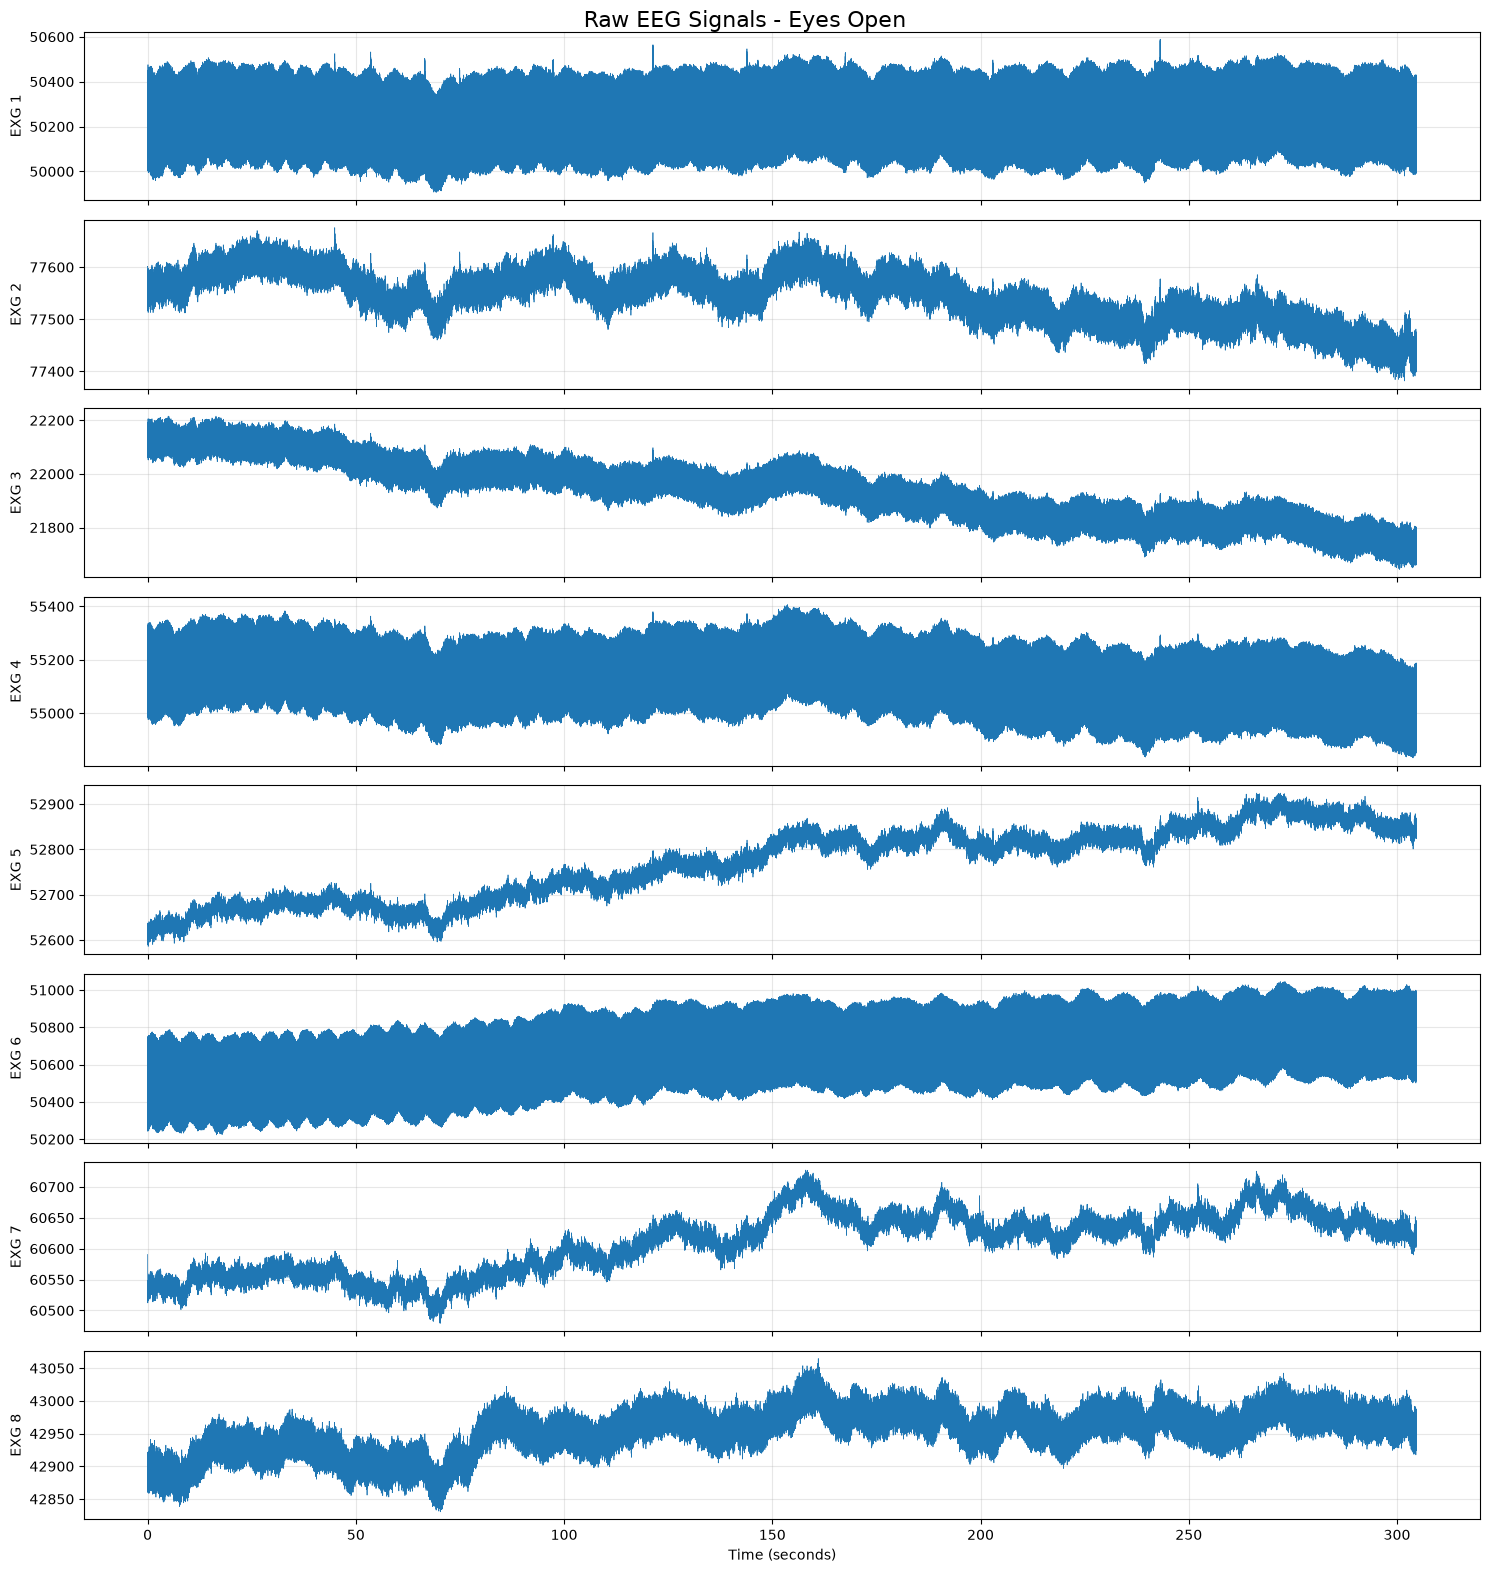

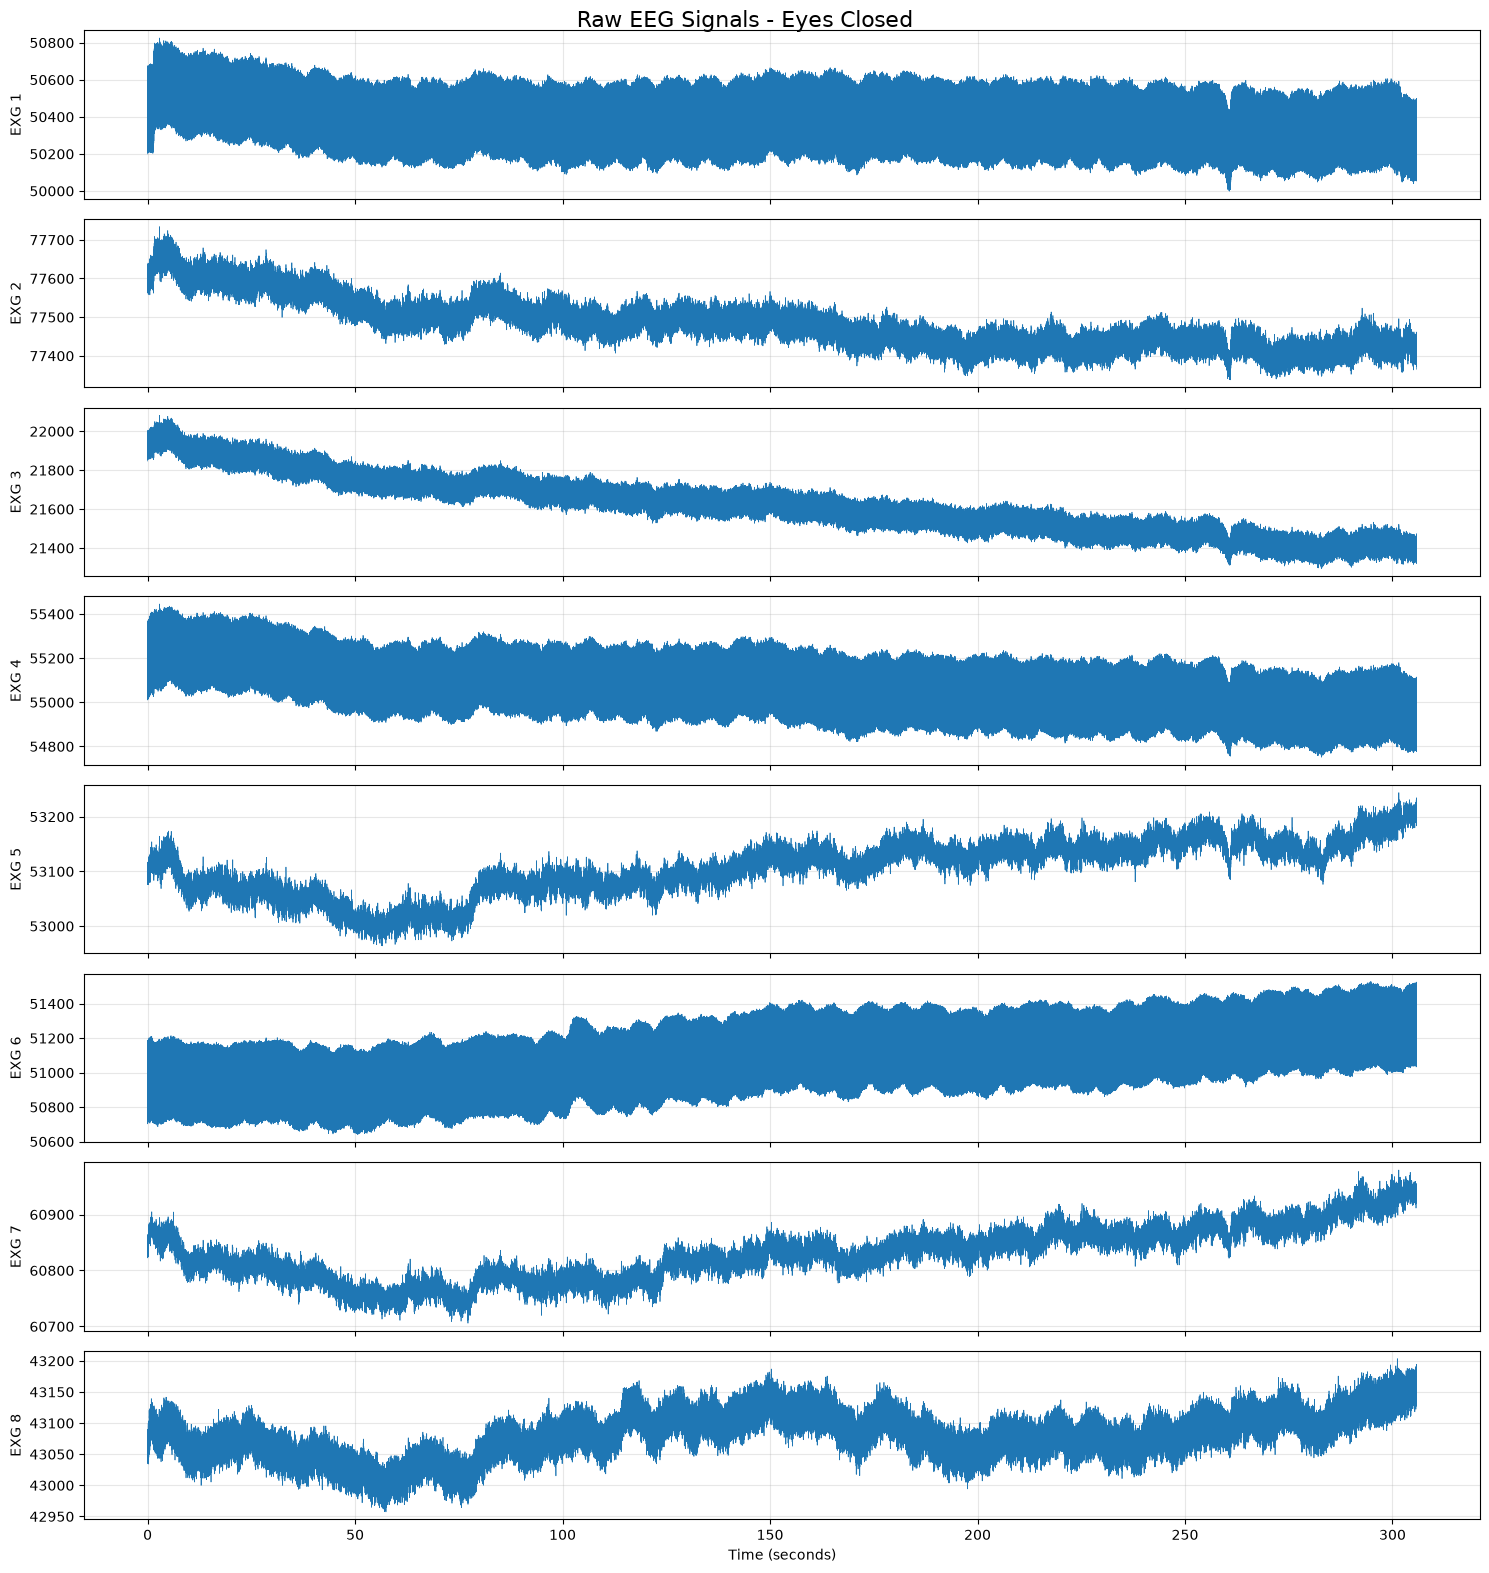

In [8]:
# Sampling frequency
sampling_rate = 250

# Create time axes
time_open = np.arange(len(eyes_open)) / sampling_rate
time_closed = np.arange(len(eyes_closed)) / sampling_rate

# Create figure for Eyes Open
fig, axes = plt.subplots(8, 1, figsize=(15, 16), sharex=True)

fig.suptitle("Raw EEG Signals - Eyes Open", fontsize=16)

for i, channel in enumerate(eeg_channels):
    axes[i].plot(time_open, eyes_open[channel], linewidth=0.5)
    axes[i].set_ylabel(channel)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()


# Create figure for Eyes Closed
fig, axes = plt.subplots(8, 1, figsize=(15, 16), sharex=True)

fig.suptitle("Raw EEG Signals - Eyes Closed", fontsize=16)

for i, channel in enumerate(eeg_channels):
    axes[i].plot(time_closed, eyes_closed[channel], linewidth=0.5)
    axes[i].set_ylabel(channel)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

## 6. EEG Preprocessing

The raw EEG signals are preprocessed using a 4th-order Butterworth bandpass filter from 0.5–40 Hz and a 50 Hz notch filter with a quality factor of 30. Forward-backward filtering is used to avoid phase distortion in the EEG signals.

In [9]:
# Filtering parameters

low_cutoff = 0.5
high_cutoff = 40
notch_frequency = 50
quality_factor = 30

# Design Butterworth band-pass filter

bandpass_filter = butter(
    4,
    [low_cutoff, high_cutoff],
    btype="bandpass",
    fs=sampling_rate,
    output="sos"
)

# Design 50 Hz notch filter

b_notch, a_notch = iirnotch(
    notch_frequency,
    quality_factor,
    fs=sampling_rate
)


# Define preprocessing function

def preprocess_eeg(data):

    filtered = sosfiltfilt(
        bandpass_filter,
        data,
        axis=0
    )

    filtered = filtfilt(
        b_notch,
        a_notch,
        filtered,
        axis=0
    )

    return filtered


print("EEG preprocessing function created successfully!")

EEG preprocessing function created successfully!


### Apply Preprocessing to EEG Signals

The selected EEG channels are converted into NumPy arrays, and the preprocessing function is applied to both the eyes-open and eyes-closed recordings.

In [10]:
# Extract EEG channel data as NumPy arrays

raw_open = eyes_open[eeg_channels].to_numpy(dtype=float)
raw_closed = eyes_closed[eeg_channels].to_numpy(dtype=float)

# Apply preprocessing

filtered_open = preprocess_eeg(raw_open)
filtered_closed = preprocess_eeg(raw_closed)

# Display shapes

print("Eyes-open filtered data shape:", filtered_open.shape)
print("Eyes-closed filtered data shape:", filtered_closed.shape)

print("\nEEG preprocessing completed successfully!")

Eyes-open filtered data shape: (76175, 8)
Eyes-closed filtered data shape: (76451, 8)

EEG preprocessing completed successfully!


## 7. Raw vs Filtered EEG Comparison

The raw and preprocessed EEG signals are compared for all eight channels under both eyes-open and eyes-closed conditions. This visualization helps demonstrate the effect of preprocessing on the EEG recordings before frequency-domain analysis.

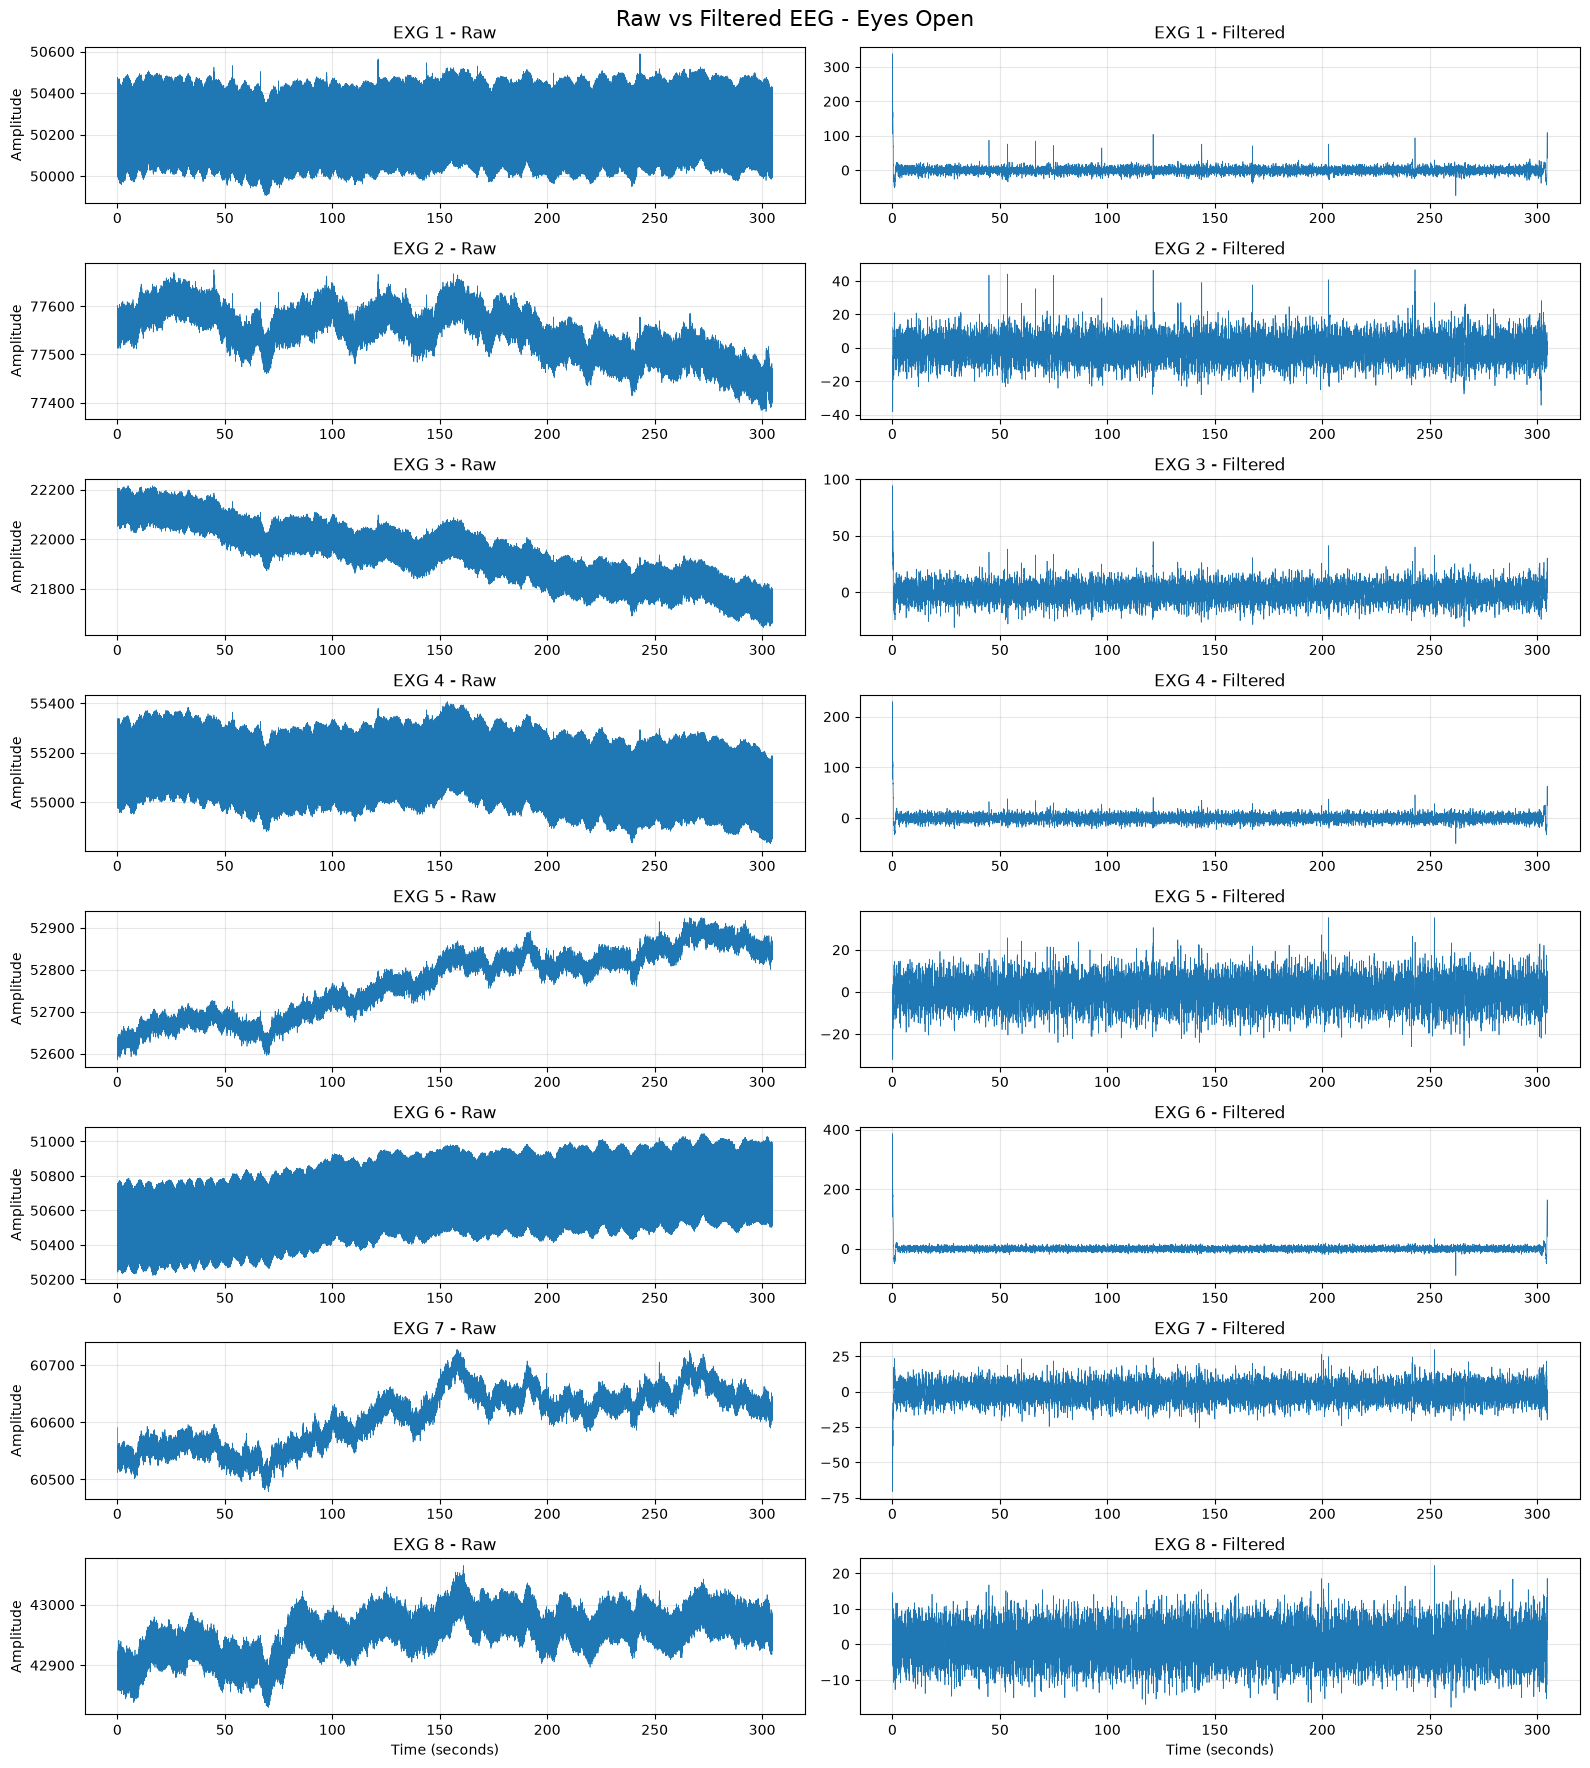

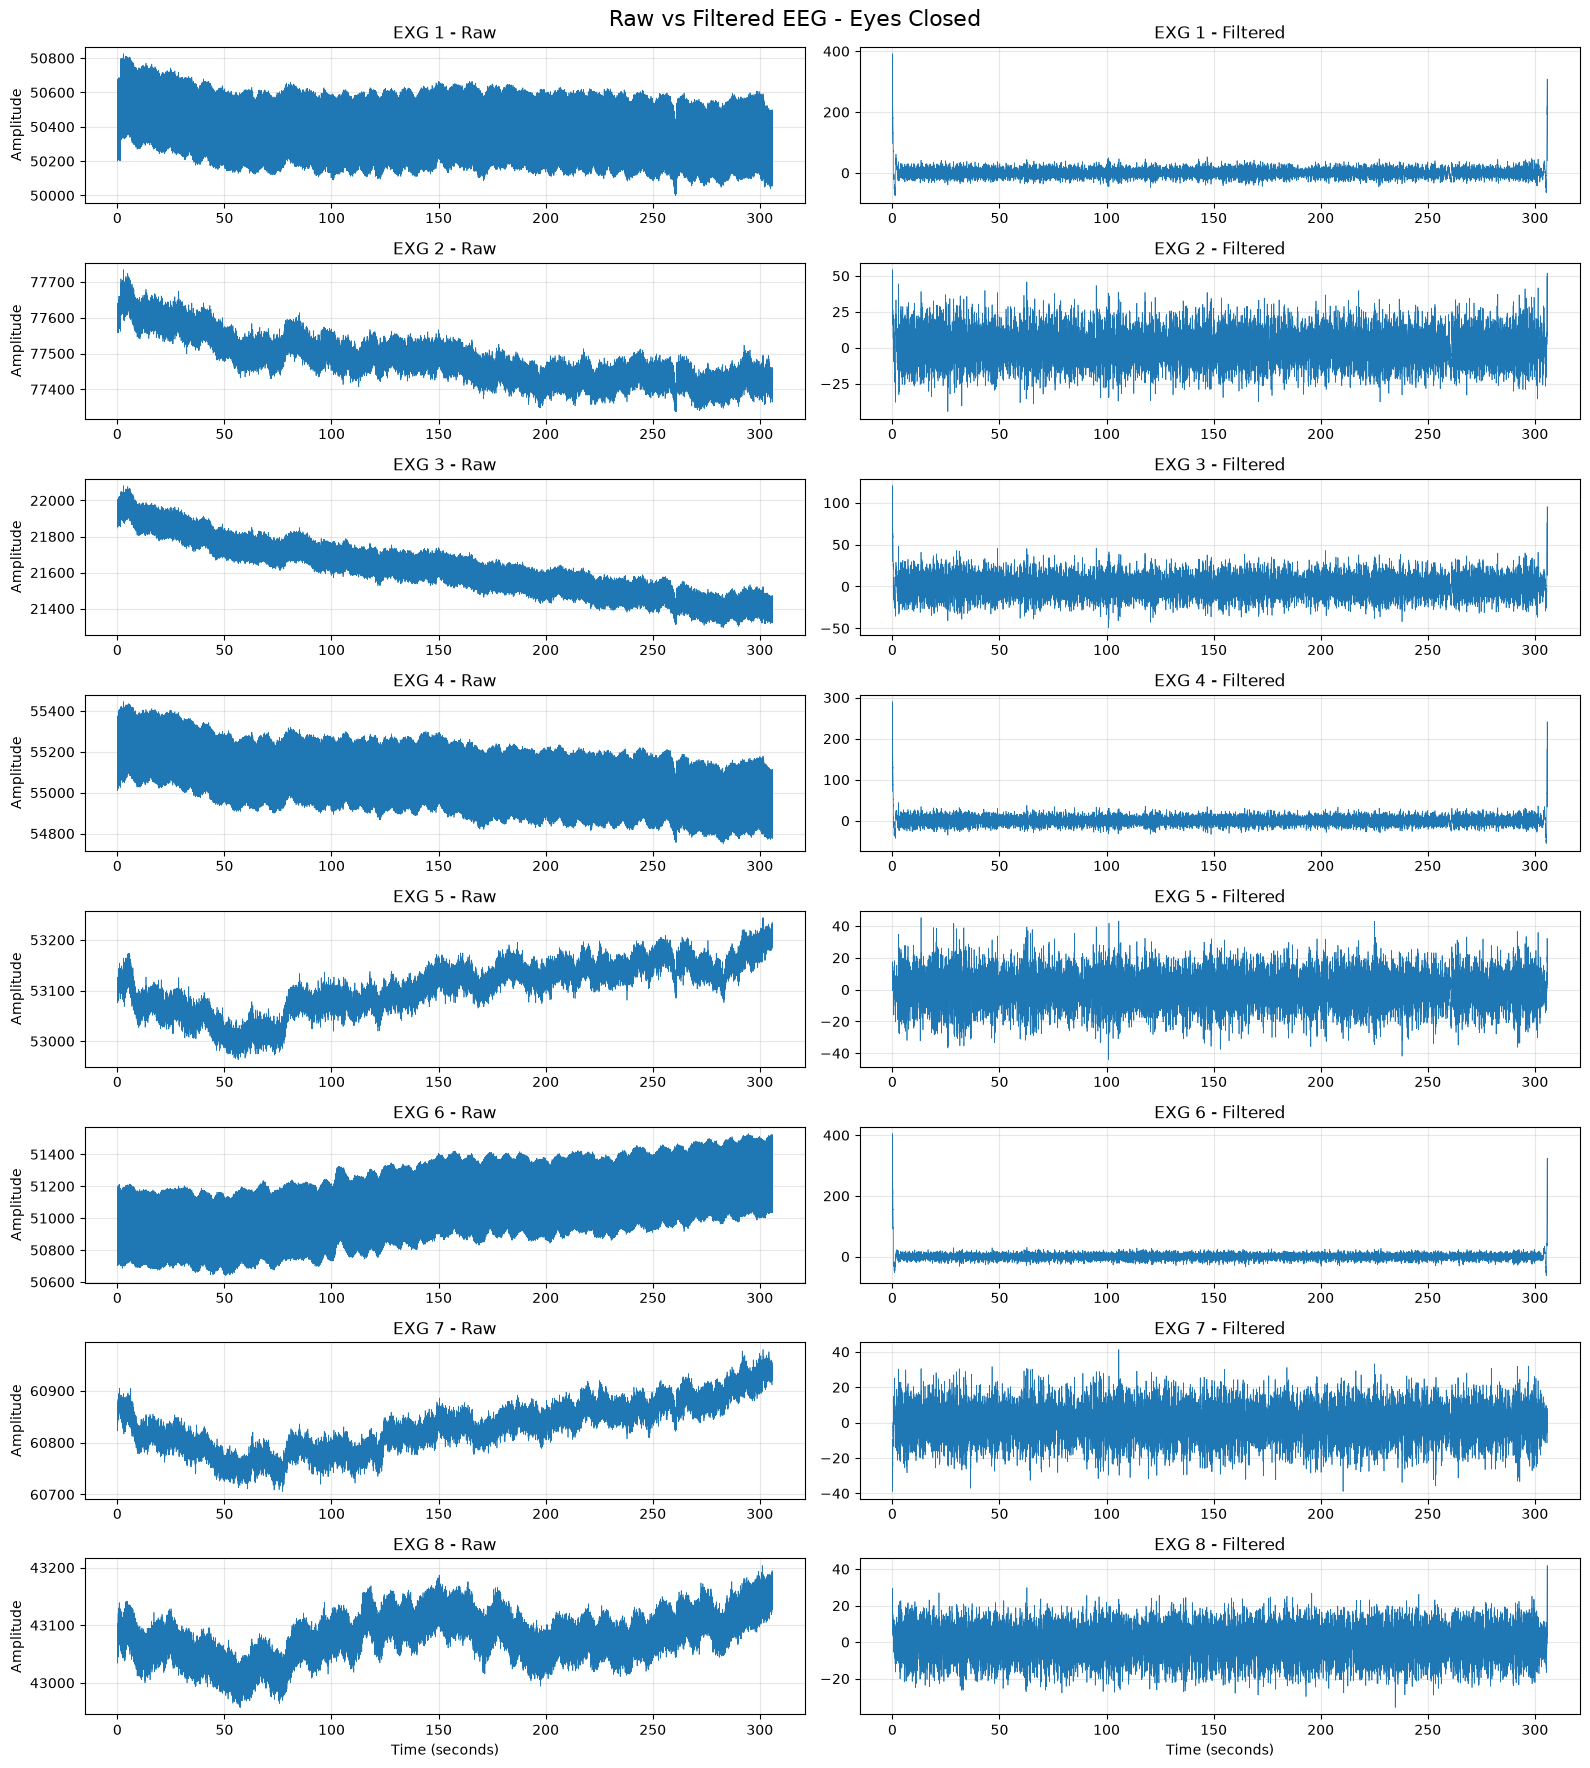

In [11]:
# Create time axes
time_open = np.arange(len(raw_open)) / sampling_rate
time_closed = np.arange(len(raw_closed)) / sampling_rate

# Plot raw vs filtered - Eyes Open
fig, axes = plt.subplots(8, 2, figsize=(16, 18))

fig.suptitle("Raw vs Filtered EEG - Eyes Open", fontsize=16)

for i, channel in enumerate(eeg_channels):

    axes[i, 0].plot(time_open, raw_open[:, i], linewidth=0.5)
    axes[i, 0].set_title(f"{channel} - Raw")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(time_open, filtered_open[:, i], linewidth=0.5)
    axes[i, 1].set_title(f"{channel} - Filtered")
    axes[i, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()


# Plot raw vs filtered - Eyes Closed
fig, axes = plt.subplots(8, 2, figsize=(16, 18))

fig.suptitle("Raw vs Filtered EEG - Eyes Closed", fontsize=16)

for i, channel in enumerate(eeg_channels):

    axes[i, 0].plot(time_closed, raw_closed[:, i], linewidth=0.5)
    axes[i, 0].set_title(f"{channel} - Raw")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(time_closed, filtered_closed[:, i], linewidth=0.5)
    axes[i, 1].set_title(f"{channel} - Filtered")
    axes[i, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

## 8. Power Spectral Density (PSD) Using Welch's Method

Power Spectral Density (PSD) is estimated from the preprocessed EEG signals using Welch's method. A 5-second segment length is used with overlapping segments to estimate the distribution of EEG signal power across frequencies for both eyes-open and eyes-closed conditions.

In [12]:
# Welch parameters

nperseg = 5 * sampling_rate
noverlap = nperseg - int(0.5 * sampling_rate)

# Calculate PSD for Eyes Open

frequencies_open, psd_open = welch(
    filtered_open,
    fs=sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    axis=0
)

# Calculate PSD for Eyes Closed

frequencies_closed, psd_closed = welch(
    filtered_closed,
    fs=sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    axis=0
)

print("Eyes-open PSD shape:", psd_open.shape)
print("Eyes-closed PSD shape:", psd_closed.shape)

print("\nPSD calculation completed successfully!")

Eyes-open PSD shape: (626, 8)
Eyes-closed PSD shape: (626, 8)

PSD calculation completed successfully!


### PSD Comparison: Eyes Open vs Eyes Closed

The Power Spectral Density (PSD) of the eyes-open and eyes-closed EEG recordings is compared across all eight channels over the 0–40 Hz frequency range. This visualization helps identify differences in frequency-domain activity between the two conditions, particularly within the alpha band (8–12 Hz).

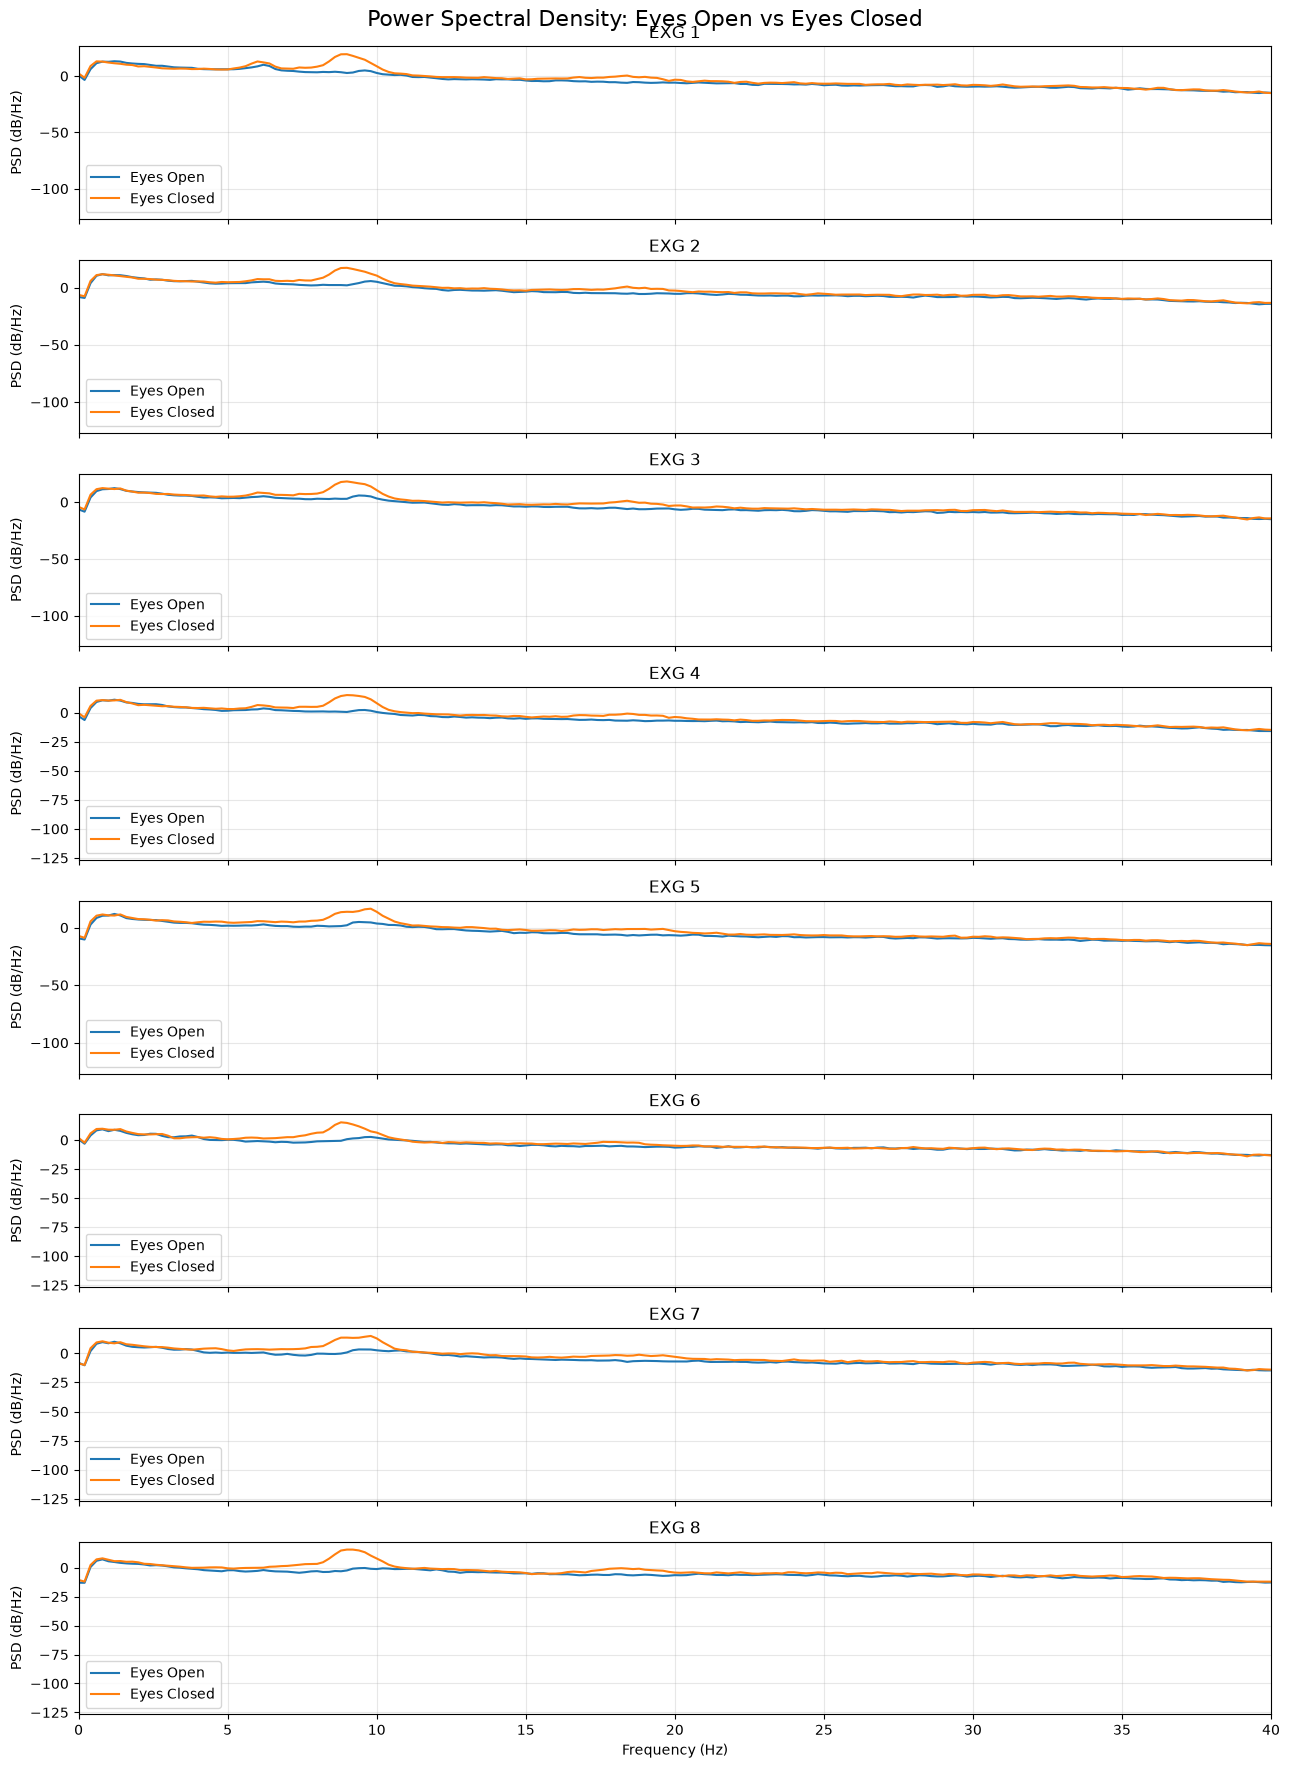

In [13]:
# Plot PSD comparison for all eight channels

fig, axes = plt.subplots(8, 1, figsize=(13, 18), sharex=True)

fig.suptitle(
    "Power Spectral Density: Eyes Open vs Eyes Closed",
    fontsize=16
)

for i, channel in enumerate(eeg_channels):

    axes[i].plot(
        frequencies_open,
        10 * np.log10(psd_open[:, i] + 1e-12),
        label="Eyes Open"
    )

    axes[i].plot(
        frequencies_closed,
        10 * np.log10(psd_closed[:, i] + 1e-12),
        label="Eyes Closed"
    )

    axes[i].set_ylabel("PSD (dB/Hz)")
    axes[i].set_title(channel)
    axes[i].set_xlim(0, 40)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

## 9. Alpha Power Extraction

Alpha-band power is calculated from the preprocessed EEG signals in the 8–12 Hz frequency range. The recordings are divided into non-overlapping 5-second windows. Welch's method is used to estimate the PSD within each window, and the PSD values from 8–12 Hz are integrated using the trapezoidal method to obtain alpha power for each EEG channel.

In [14]:
# Alpha frequency range
alpha_low = 8
alpha_high = 12

# Window size: 5 seconds
window_size = 5 * sampling_rate

# Function to calculate alpha power

def calculate_alpha_power(data, sampling_rate):

    alpha_power = []

    for start in range(0, len(data) - window_size + 1, window_size):

        window = data[start:start + window_size, :]

        frequencies, psd = welch(
            window,
            fs=sampling_rate,
            nperseg=window_size,
            axis=0
        )

        alpha_mask = (
            (frequencies >= alpha_low) &
            (frequencies <= alpha_high)
        )

        alpha_values = np.trapezoid(
            psd[alpha_mask, :],
            x=frequencies[alpha_mask],
            axis=0
        )

        alpha_power.append(alpha_values)

    return np.array(alpha_power)


# Calculate alpha power for both conditions

alpha_open = calculate_alpha_power(
    filtered_open,
    sampling_rate
)

alpha_closed = calculate_alpha_power(
    filtered_closed,
    sampling_rate
)

print("Eyes-open alpha power shape:", alpha_open.shape)
print("Eyes-closed alpha power shape:", alpha_closed.shape)

print("\nAlpha power extraction completed successfully!")

Eyes-open alpha power shape: (60, 8)
Eyes-closed alpha power shape: (61, 8)

Alpha power extraction completed successfully!


### Alpha Power Comparison

The mean alpha power is calculated for each of the eight EEG channels under both eyes-open and eyes-closed conditions. The results are organized into a comparison table to show the difference in alpha-band activity between the two conditions.

In [15]:
# Calculate mean alpha power for each channel

mean_alpha_open = np.mean(alpha_open, axis=0)
mean_alpha_closed = np.mean(alpha_closed, axis=0)

# Create comparison table

alpha_comparison = pd.DataFrame({
    "Channel": eeg_channels,
    "Eyes Open Alpha Power": mean_alpha_open,
    "Eyes Closed Alpha Power": mean_alpha_closed
})

display(alpha_comparison)

,Channel,Eyes Open Alpha Power,Eyes Closed Alpha Power
0,EXG 1,7.427451,88.276146
1,EXG 2,7.561394,62.551962
2,EXG 3,7.438652,76.532962
3,EXG 4,4.136810,40.775404
4,EXG 5,6.911824,51.617666
5,EXG 6,4.585923,34.234664
6,EXG 7,5.946453,43.544745
7,EXG 8,2.796961,42.383000


### Alpha Power Visualization

The mean alpha power for eyes-open and eyes-closed conditions is visualized using a grouped bar chart across all eight EEG channels. The graph provides a clear visual comparison of alpha-band activity between the two conditions.

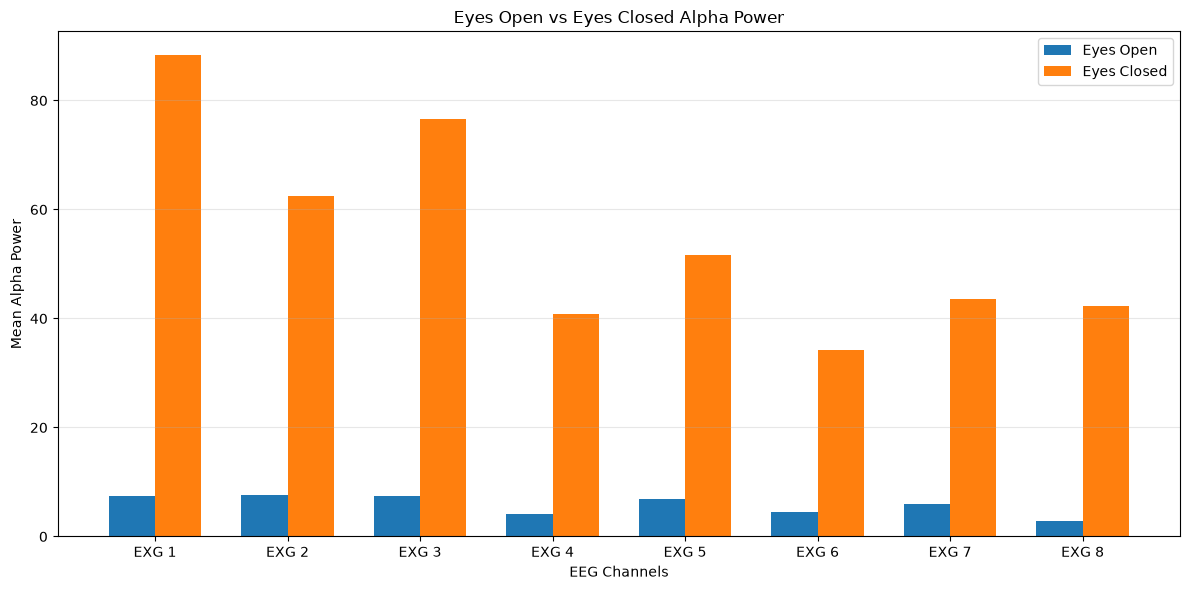

In [16]:
x = np.arange(len(eeg_channels))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    mean_alpha_open,
    width,
    label="Eyes Open"
)

plt.bar(
    x + width/2,
    mean_alpha_closed,
    width,
    label="Eyes Closed"
)

plt.xticks(x, eeg_channels)
plt.xlabel("EEG Channels")
plt.ylabel("Mean Alpha Power")
plt.title("Eyes Open vs Eyes Closed Alpha Power")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Descriptive Statistics

Descriptive statistics are calculated for the alpha-power values of each EEG channel. The table reports the mean alpha power, standard deviation, and number of 5-second windows for both eyes-open and eyes-closed conditions.

In [17]:
# Calculate descriptive statistics

mean_open = np.mean(alpha_open, axis=0)
mean_closed = np.mean(alpha_closed, axis=0)

sd_open = np.std(alpha_open, axis=0, ddof=1)
sd_closed = np.std(alpha_closed, axis=0, ddof=1)

# Create results table

statistical_results = pd.DataFrame({
    "Channel": eeg_channels,
    "Mean Alpha Open": mean_open,
    "Mean Alpha Closed": mean_closed,
    "SD Alpha Open": sd_open,
    "SD Alpha Closed": sd_closed,
    "Number of Windows Open": len(alpha_open),
    "Number of Windows Closed": len(alpha_closed)
})

display(statistical_results)

,Channel,Mean Alpha Open,Mean Alpha Closed,SD Alpha Open,SD Alpha Closed,Number of Windows Open,Number of Windows Closed
0,EXG 1,7.427451,88.276146,2.989757,35.797825,60,61
1,EXG 2,7.561394,62.551962,3.169186,23.573191,60,61
2,EXG 3,7.438652,76.532962,2.800643,31.278513,60,61
3,EXG 4,4.136810,40.775404,1.593798,17.213976,60,61
4,EXG 5,6.911824,51.617666,2.827384,22.491545,60,61
5,EXG 6,4.585923,34.234664,2.241354,15.455885,60,61
6,EXG 7,5.946453,43.544745,3.390489,17.951956,60,61
7,EXG 8,2.796961,42.383000,0.993814,13.309925,60,61


## 11. Save Analysis Results

The final alpha-power comparison and descriptive statistics are saved as CSV files for further analysis, documentation, and reproducibility.

In [18]:
# Create results folder

results_folder = Path.home() / "Downloads" / "EEG_Final_Results"
results_folder.mkdir(parents=True, exist_ok=True)

# Save CSV files

alpha_comparison.to_csv(
    results_folder / "alpha_power_results.csv",
    index=False
)

statistical_results.to_csv(
    results_folder / "statistical_results.csv",
    index=False
)

print("Results saved successfully!")
print("Location:", results_folder)

Results saved successfully!
Location: C:\Users\Shravan\Downloads\EEG_Final_Results


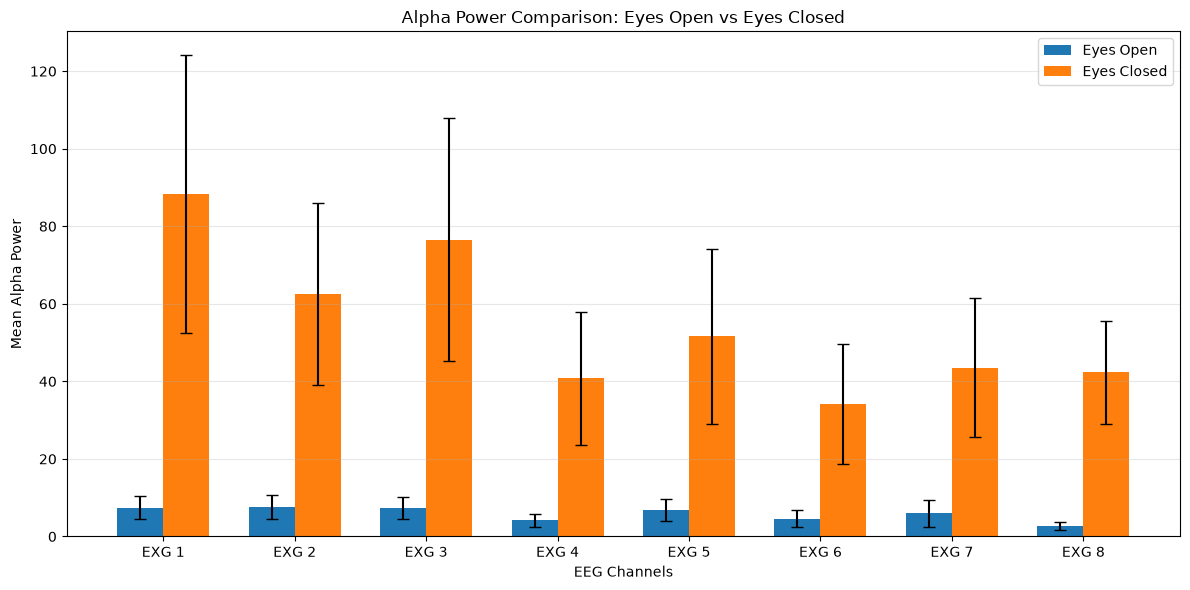

In [19]:
import matplotlib.pyplot as plt
import numpy as np

channels = statistical_results["Channel"]

open_mean = statistical_results["Mean Alpha Open"]
closed_mean = statistical_results["Mean Alpha Closed"]

open_sd = statistical_results["SD Alpha Open"]
closed_sd = statistical_results["SD Alpha Closed"]

x = np.arange(len(channels))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    open_mean,
    width,
    yerr=open_sd,
    capsize=4,
    label="Eyes Open"
)

plt.bar(
    x + width/2,
    closed_mean,
    width,
    yerr=closed_sd,
    capsize=4,
    label="Eyes Closed"
)

plt.xlabel("EEG Channels")
plt.ylabel("Mean Alpha Power")
plt.title("Alpha Power Comparison: Eyes Open vs Eyes Closed")

plt.xticks(x, channels)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Check the number of alpha-power windows

print("Eyes Open Alpha Power Shape:", alpha_open.shape)
print("Eyes Closed Alpha Power Shape:", alpha_closed.shape)

print("\nEyes Open Windows:", len(alpha_open))
print("Eyes Closed Windows:", len(alpha_closed))

print("\nNumber of EEG Channels:", alpha_open.shape[1])

Eyes Open Alpha Power Shape: (60, 8)
Eyes Closed Alpha Power Shape: (61, 8)

Eyes Open Windows: 60
Eyes Closed Windows: 61

Number of EEG Channels: 8


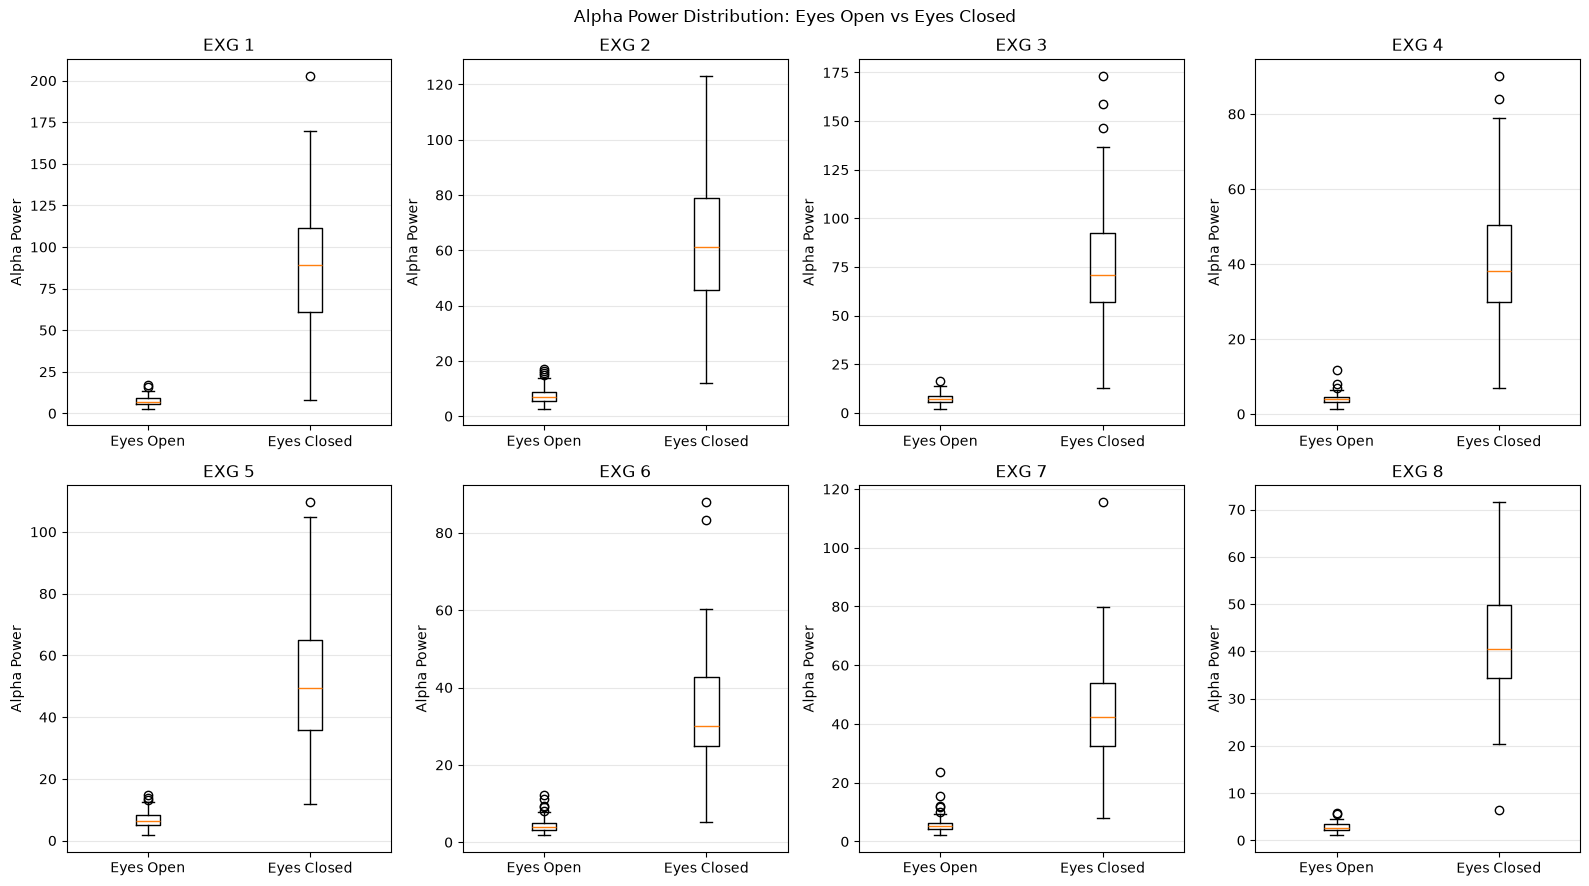

In [21]:
# Compare alpha power distributions across all EEG channels

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for ch in range(8):
    ax = axes[ch // 4, ch % 4]

    ax.boxplot(
        [alpha_open[:, ch], alpha_closed[:, ch]],
        tick_labels=["Eyes Open", "Eyes Closed"]
    )

    ax.set_title(f"EXG {ch + 1}")
    ax.set_ylabel("Alpha Power")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Alpha Power Distribution: Eyes Open vs Eyes Closed")
plt.tight_layout()
plt.show()

In [22]:
# Calculate the difference in mean alpha power

for ch in range(8):

    open_mean = np.mean(alpha_open[:, ch])
    closed_mean = np.mean(alpha_closed[:, ch])

    difference = closed_mean - open_mean

    print(f"EXG {ch + 1}")
    print(f"Eyes Open Mean: {open_mean:.4f}")
    print(f"Eyes Closed Mean: {closed_mean:.4f}")
    print(f"Difference: {difference:.4f}")
    print("-" * 35)

EXG 1
Eyes Open Mean: 7.4275
Eyes Closed Mean: 88.2761
Difference: 80.8487
-----------------------------------
EXG 2
Eyes Open Mean: 7.5614
Eyes Closed Mean: 62.5520
Difference: 54.9906
-----------------------------------
EXG 3
Eyes Open Mean: 7.4387
Eyes Closed Mean: 76.5330
Difference: 69.0943
-----------------------------------
EXG 4
Eyes Open Mean: 4.1368
Eyes Closed Mean: 40.7754
Difference: 36.6386
-----------------------------------
EXG 5
Eyes Open Mean: 6.9118
Eyes Closed Mean: 51.6177
Difference: 44.7058
-----------------------------------
EXG 6
Eyes Open Mean: 4.5859
Eyes Closed Mean: 34.2347
Difference: 29.6487
-----------------------------------
EXG 7
Eyes Open Mean: 5.9465
Eyes Closed Mean: 43.5447
Difference: 37.5983
-----------------------------------
EXG 8
Eyes Open Mean: 2.7970
Eyes Closed Mean: 42.3830
Difference: 39.5860
-----------------------------------


In [23]:
# Create a DataFrame for alpha power differences

difference_results = pd.DataFrame({
    "Channel": [f"EXG {i}" for i in range(1, 9)],
    "Eyes Open Mean": np.mean(alpha_open, axis=0),
    "Eyes Closed Mean": np.mean(alpha_closed, axis=0),
    "Alpha Power Difference": (
        np.mean(alpha_closed, axis=0)
        - np.mean(alpha_open, axis=0)
    )
})

# Save results
difference_results.to_csv(
    results_folder / "alpha_power_differences.csv",
    index=False
)

print("Alpha power difference results saved successfully!")
display(difference_results)

Alpha power difference results saved successfully!


,Channel,Eyes Open Mean,Eyes Closed Mean,Alpha Power Difference
0,EXG 1,7.427451,88.276146,80.848695
1,EXG 2,7.561394,62.551962,54.990567
2,EXG 3,7.438652,76.532962,69.094310
3,EXG 4,4.136810,40.775404,36.638595
4,EXG 5,6.911824,51.617666,44.705841
5,EXG 6,4.585923,34.234664,29.648741
6,EXG 7,5.946453,43.544745,37.598292
7,EXG 8,2.796961,42.383000,39.586039


In [24]:
# List all saved analysis results

print("Results folder:", results_folder)

for file in sorted(results_folder.iterdir()):
    if file.is_file():
        print(file.name)

Results folder: C:\Users\Shravan\Downloads\EEG_Final_Results
alpha_power_differences.csv
alpha_power_results.csv
statistical_results.csv
